In [1]:
import math
from matplotlib import pyplot as plt
import numpy as np
import sys

In [2]:
def get_exp(lmda):
    '''
    returns a realization of the exponential(lambda) distribution
    Args:
        lmda (float, > 0): the rate of the exponential distribution (mean = 1/lmda)
    Returns:
        a realization from the exp(lmda) distribution (float, > 0)
    '''
    u = np.random.rand()
    x = -1/lmda*math.log(u)
    return x

### CH12 Q4

In [3]:
def product(x):
    '''
    Computes the product of all elements in x
    Args:
        x (np.array(float)): vector of elements
    Returns:
        the product (float)
    '''
    prod = 1
    for xval in x:
        prod *= xval
    return prod

def get_all_except_one(vec, index):
    '''
    Returns all elements of vec except the one at position index
    Args:
        vec (numpy.array(float)): vector of elements
        index (int, [0, len(vec)-1]): index to exclude
    Returns:
        vector of elements (np.array(float))
    '''
    output = []
    for i in range(len(vec)):
        if(i!=index):
            output.append(vec[i])
    return np.array(output)

def get_required_vector_q4(warmup_period):
    '''
    Returns the required vector of 10 independent exponentials with mean(1) satisfying that their product > 20
    (using MCMC based method (Gibbs sampling)) 
    Args:
        warmup_period (int): number of initial samples to be left
    Returns:
        the required vector (numpy.array(float))
    '''
    n = 10
    # Creating initial point
    while(True):
        xv_init = np.zeros(n)
        for i in range(n):
            xv_init[i] = get_exp(1)
        prod = product(xv_init)
        if(prod>20):
            break 
    # Starting the chain
    xv_new = xv_init.copy()
    # Burning out initial samples
    for _ in range(warmup_period):
        u = np.random.rand()
        I = math.floor(n*u)
        vmI = get_all_except_one(xv_new, I)
        prod_all_except_I = product(vmI)
        # Adding this number ensures that xnew>20/prod_all_except_I which is what we require
        xnew = get_exp(1) + 20/prod_all_except_I
        xv_new[I] = xnew
    return xv_new

In [5]:
output = get_required_vector_q4(20)
print(output)
print(product(output))

[1.60373685 7.50601559 0.55400446 1.01539678 2.95283017 0.45437028
 2.20171403 0.55738233 0.67329503 2.98853115]
22.434546323144527


In [6]:
# n = 10
# while(True):
#     xv_init = np.zeros(n)
#     for i in range(n):
#         xv_init[i] = get_exp(1)
#     prod = product(xv_init)
#     if(prod>20):
#         print(prod)
#         break 
# print(xv_init)   

In [7]:
# xv_new = xv_init.copy()

# #? How long to run: How many iterations on I
# u = np.random.rand()
# I = math.floor(n*u)
# vmI = get_all_except_one(xv_new, I)
# prod_all_except_I = product(vmI)
# # Adding this number ensures that xnew>20/prod_all_except_I which is what we require
# xnew = get_exp(1) + 20/prod_all_except_I
# xv_new[I] = xnew
# print(xv_new)
# print(product(xv_new))


### CH12 Q5

In [8]:
# If a1 = a2 = ... = an, this is same as generating n U[0, 1] and sorting them out!
def get_required_vector_q5(a, warmup_period):
    '''
    Simulates a vector x whose distribution is same as that of U1, U2, ..., Un (n iid U[0, 1]) conditional on 
    a1U1<a2U2<...<anUn (where a1>a2>...>an)
    Args:
        a (numpy.array(float)): the vector of coefficients used in the condition to be satisfied
        warmup_period (int): the initial period which is to be burnt out (or left)
    Returns:
        the desired vector (or sequence) i.e. a sequence of iid U[0, 1] satisfying the required condition of a*U (numpy.array(float))
    '''
    # Creating the initial feasible state
    # Issue with method 1 (if the first few elements are wrongly set, the while loop will never stop; for eg: a = [3, 2, 1] and u[0] = 0.8 => 3*0.8<2*x = x>1.2 which is not possible in U[0, 1])
    # n = len(a)
    # uv_init = np.zeros(n)
    # uv_init[0] = np.random.rand()
    # for i in range(1, n):
    #     while(True):
    #         u = np.random.rand()
    #         if(u>a[i-1]*uv_init[i-1]/a[i]):
    #             uv_init[i] = u
    #             break
    
    n = len(a)
    while(True):
        uv_init = [np.random.rand() for _ in range(n)]
        cond = True
        for i in range(1, n):
            if(a[i-1]*uv_init[i-1]>=a[i]*uv_init[i]):
                cond = False
                break
        if(cond == True):
            break

    uv_new = uv_init.copy()
    for _ in range(warmup_period):
        u = np.random.rand()
        I = math.floor(u*n)
        if(I == 0):
            val = a[1]*uv_new[1]/a[0]*np.random.rand()
        elif(I == n-1):
            val = a[n-2]*uv_new[n-2]/a[n-1] + (1 - a[n-2]*uv_new[n-2]/a[n-1])*np.random.rand()
        else:
            val = a[I-1]*uv_new[I-1]/a[I] + (a[I+1]*uv_new[I+1]/a[I] - a[I-1]*uv_new[I-1]/a[I])*np.random.rand() 
        uv_new[I] = val
    return uv_new

In [9]:
a = np.array([5-i for i in range(5)])
warmup_period = 20
uvec = get_required_vector_q5(a, warmup_period)
print(uvec)
print(uvec*a)

[np.float64(0.031152040687605343), np.float64(0.060634942220366236), np.float64(0.13056424474566009), np.float64(0.3671443334064825), np.float64(0.9951992860315994)]
[0.1557602  0.24253977 0.39169273 0.73428867 0.99519929]


### CH12 Q9

In [10]:
const = np.array([1, 2, 3])
lmda = 1

#### (i)

##### Using MCMC based techniques (Gibbs Sampling)

In [11]:
def get_expectation_q9_1(warmup_period, num_iters):
    '''
    Returns the expectation as desired in CH12 Q9 (a)
    Args:
        warmup_period (int): the initial period that needs to be left behind (not considered in average computation)
        num_iters (int): the number of iterations (starting after warmup period) over which the average is computed
    Returns:
        the average (float)
    '''
    n = 3
    
    # Creating initial point
    while(True):
        xv_init = np.zeros(n)
        for i in range(n):
            xv_init[i] = get_exp(lmda)
        if(const.T@xv_init > 15):
            break 
    
    ans = 0
    # Starting the chain
    xv_new = xv_init.copy()
    # Burning out initial samples
    for itr in range(warmup_period+num_iters):
        u = np.random.rand()
        I = math.floor(n*u)
        temp = const.copy()
        temp[I] = 0
        delta = 15-temp.T@xv_new
        delta /= const[I]
        xv_new[I] = get_exp(lmda) + max(delta, 0)
        if(itr >= warmup_period):
            ans += const.T@xv_new
    ans = ans/num_iters
    return ans

ans = get_expectation_q9_1(20, 10000)
print(ans)

18.031733254905067


##### Using direct and raw sampling

In [14]:
ans = 0
cnt = 0
lmda = 1
while(cnt<10000):
    x1 = get_exp(lmda)
    x2 = get_exp(lmda)
    x3 = get_exp(lmda)
    qty = x1 + 2*x2 + 3*x3
    if(qty>15):
        ans += qty
        cnt += 1
ans = ans/cnt
print(ans)

18.056454149469776


#### (ii)

##### Using MCMC based techniques (Gibbs Sampling)

In [15]:
def get_expectation_q9_2(warmup_period, num_iters):
    '''
    Returns the expectation as desired in CH12 Q9 (b)
    Args:
        warmup_period (int): the initial period that needs to be left behind (not considered in average computation)
        num_iters (int): the number of iterations (starting after warmup period) over which the average is computed
    Returns:
        the average (float)
    '''
    n = 3
    # Creating initial point
    while(True):
        xv_init = np.zeros(n)
        for i in range(n):
            xv_init[i] = get_exp(lmda)
        if(const.T@xv_init < 1):
            break 
    
    ans = 0
    # Starting the chain
    xv_new = xv_init.copy()
    # Burning out initial samples
    for itr in range(warmup_period+num_iters):
        u = np.random.rand()
        I = math.floor(n*u)
        temp = const.copy()
        temp[I] = 0
        delta = 1-temp.T@xv_new
        delta /= const[I]
        # Now, xnew should be < delta; define alpha as cdf(delta)
        alpha = 1-math.exp(-lmda*delta)
        xv_new[I] = -1/lmda*math.log(1-alpha*np.random.rand()) 
        if(itr>=warmup_period):
            ans += const.T@xv_new
    ans = ans/num_iters
    return ans

ans = get_expectation_q9_2(20, 10000)
print(ans)

0.7227081034545204


##### Using direct simulation

In [16]:
ans = 0
cnt = 0
lmda = 1
while(cnt<10000):
    x1 = get_exp(lmda)
    x2 = get_exp(lmda)
    x3 = get_exp(lmda)
    qty = x1 + 2*x2 + 3*x3
    if(qty<1):
        ans += qty
        cnt += 1
ans = ans/cnt
print(ans)

0.7274664820074054


### CH12 Q13

In [17]:
# def generate_required_vector_q13(n):
#     '''
#     Generates required vector for Q13
#     Args:
#         n (int): the length of the permutation
#     Returns:
#         the permutation satisfying the required condition
#     '''

#     def cond(v):
#         sum = 0
#         for i in range(len(v)):
#             sum += (i+1)*v[i]
#         return sum>285000
    
#     while(True):
#         v = generate_permutation(n)
#         if(cond(v)):
#             return v

# output = generate_required_vector_q13(100)
# print(output)

In [18]:
def generate_permutation(n):
    '''
    Given n, this function generates a random permutation of the sequence[1, 2, ..., n] (using algorithm in example 4b of the book)
    Args:
        n (int): the length of the permutation (permutation of 1 to n)
    Returns:
        the desired permutation (numpy.array(int))
    '''
    perm = np.array([i+1 for i in range(n)])
    # k represents the number of variables left to be adjusted
    k = n
    while(k>1):
        u = np.random.rand()
        I = math.floor(k*u)
        # Interchange perm[I] and perm[k]
        temp = perm[k-1]
        perm[k-1] = perm[I]
        perm[I] = temp
        k = k-1
    return perm

def check_sum_condition(v):
    '''
    Checks whether the sum condition (of Q13) is satisfied for the given vector v
    Args:
        v (numpy.array(int)): the vector to check
    Returns:
        True if the condition is satisfied else False (bool)
    '''
    sum = 0
    n = len(v)
    for i in range(n):
        sum += (i+1)*v[i]
    return sum > 285000

def generate_index(weights):
    '''
    Given a vector of weights, this function generates index i with probability w[i]/sum(w[i]) (i.e. proportional to its weight)
    Args:
        weights (numpy.array(float)): vector of weights
    Returns:
        the desired index (generated from the probability distribution w[i]/sum(w[i])) (int)
    '''
    n = len(weights)
    weights_cdf = np.zeros(n)
    weights_cdf[0] = weights[0]
    for i in range(n):
        weights_cdf[i] = weights_cdf[i-1] + weights[i]
    u = np.random.rand()
    for i in range(n):
        if(u<weights_cdf[i]):
            return i

S = 100000
n = 100
initial_set_of_permutations = [generate_permutation(n) for _ in range(S)]
weights = np.array([check_sum_condition(perm) for perm in initial_set_of_permutations])
print("List of indices where the condition is satisfied:", np.where(weights==1)[0])
index = generate_index(weights)
print("Index selected:", index)
output = initial_set_of_permutations[index]
print(output)
print("Desired sum:", np.array([i+1 for i in range(100)]).T@output)

List of indices where the condition is satisfied: [   48 12694 21390 33108 42775 50069 61124 67989 69684 74796 78935 82929
 88018 88244]
Index selected: 48
[ 83  52  28  88  30  33  22  40  16  21  19  10   6  54  66  57  37  12
   5  34   3  70  44  17  76  41  38  58  39  42  29  27  24  18  32  56
   1  81  98  71  49  72  95  68   8  26  20  60  36  25   4   9  90  35
  74  96  31  13  91  46   7  47  92  94  69  14  85   2  43  75  61  78
  97  55  11  87  48  64  59  51  15  53  80  82  89  45  63 100  79  50
  93  84  73  67  62  77  23  65  99  86]
Desired sum: 287994


### LIFO PR

In [76]:
def simulate_single_server(T, lmda, service_distribution_option, service_discipline_option): 
    '''
    Simulating M/G/1/infinity/(FIFO or PS) queue
    Args:
        T (float): total time that the system is alive (closing time of the system assuming start time = 0)
        lmda (float): rate of arrival into the system
        service_distribution_option (int): choice of the service time distribution; should be one of {1, 2, 3};
            (1-> E2 (Erlang-2,2); 2-> M (Exp-1); 3-> H2 (Hyperexp-(0.1,1/9),(0.9,9)))
        service_discipline_option (int, {1, 2, 3}): choice of service discipline; should be from {1, 2, 3}; 
            (1: FIFO, 2: PS, 3: LIFO_PR)
    Returns:
        2 lists, one containing the arrival times and the other containing departure times (list[float], list[float])
    '''
    if(service_distribution_option not in {1, 2, 3}):
        raise Exception("Only the service distributions mentioned in the question supported as of now!")
    if(service_discipline_option not in {1, 2, 3}):
        raise Exception("Service discipline option can only be 1 or 2 or 3!")
    
    def simulate_arrival(lmda):
        '''
        Simulate poisson arrival @lmda
        '''
        u = np.random.rand()
        return 1/lmda*math.log(1/u)
    
    def generate_job_size(option):
        '''
        Generate service time for a job using the given option for its distribution
        '''
        if(option == 1): # E2 (erlang-2,2) => sum of 2 iid exponentials of rate 2
            u1 = np.random.rand()
            u2 = np.random.rand()
            lmda = 2
            return 1/lmda*math.log(1/u1) + 1/lmda*math.log(1/u2)
        elif(option == 2): # M (exponential(1))
            lmda = 1
            u = np.random.rand()
            return 1/lmda*math.log(1/u)
        else: # H2 (hyperexponential)
            u1 = np.random.rand()
            if(u1<0.1): # with probability 0.1, exponential(1/9)
                lmda = 1/9
            else:
                lmda = 9 # with probability 0.9, exponential(9)
            u2 = np.random.rand()
            return 1/lmda*math.log(1/u2)
        
    def sort(s, v):
        '''
        puts s into the sorted vector v in a sorted format
        '''
        l = len(v)
        i = 0
        while(i<l and v[i]<s):
                i += 1
        # first i where v[i]>=s
        return v[:i] + [s] + v[i:]

    # Initializing state variables
    Na = 0
    Nd = 0
    n = 0
    t = 0
    td = sys.maxsize
    A = []
    D = []
    S = []
    # time remaining for that particular job; useful only in LIFO
    r = [0] # ith element is for the ith job currently in the system (no 1 lag due to index)

    # Initializing time variables
    delta = simulate_arrival(lmda)
    ta = t+delta

    while(True):
        te = min(ta, td, T)
        if(te == ta):
            if(service_discipline_option == 2): # PS
                if(n > 0):
                    i = 0
                    while(i < n):
                        S[i] -= (ta-t)/n
                        i += 1
            # Updating for the arrival
            t = ta
            Na += 1
            A.append(t) # A(Na) = t # A should be a vector
            if(service_discipline_option == 3 and n!=0): # LIFO_PR and someone already there in the system
                r.append(td - t)
            n += 1
            # Deciding (or setting the time of departure)
            if(service_discipline_option == 1): # FIFO
                if(n == 1):
                    delta = generate_job_size(service_distribution_option)
                    td = t + delta
            elif(service_discipline_option == 2): # PS
                X = generate_job_size(service_distribution_option) # job size
                S = sort(X, S)
                assert(len(S) == n)
                td = t + n*S[0]
            else: # LIFO_PR
                delta = generate_job_size(service_distribution_option)
                td = t + delta
            # Next arrival
            delta = simulate_arrival(lmda) 
            ta = t + delta
        elif(te == td):
            if(service_discipline_option == 2): # PS
                R = S[0]
                i = 0
                while(i < n-1):
                    S[i] = S[i+1] - R
                    i += 1
                S = S[:n-1]
            # Accounting for the departure
            t = td
            n -= 1
            Nd += 1
            D.append(t) # D(Nd) = t # so should be D
            # Deciding time for the next departure
            if(n == 0):
                td = sys.maxsize
            else:
                if(service_discipline_option == 1): # FIFO
                    delta = generate_job_size(service_distribution_option)
                    td = t + delta
                elif(service_discipline_option == 2): # PS
                    assert(len(S) == n)
                    td = t + n*S[0]
                else: # LIFO_PR
                    td = t + r[n]
        else:
            # stop as soon as T is reached
            return A, D

In [77]:
def populate_time_vector(event_time, k):
    '''
    Given an event time vector storing the time instances at which events occured, create (or populate) a time indexed vector tracking the number of events happened till each time index
    Args:
        event_time (list[float]): list of event times
        k (int): length of the time indexed vector that needs to be created
    Returns:
        an event time vector (list[int])
    '''
    time_vector = np.zeros(k)
    # populate time vector using event_time vector
    ne = 0
    i = 0
    j = 0
    while(i<k):
        while(i<k and i*0.2<event_time[j]):
            time_vector[i] = ne
            i += 1
        # Suppose 2 events in close context => will be taken care of in the next iteration
        if(i*0.2 >= event_time[j]):
            # an event at event_time[j] that needs to be reflected in the times henceforth
            ne += 1
            # For the next event, move to next event_time[j]
            j += 1
        if(j == len(event_time)):
            while(i<k):
                time_vector[i] = ne
                i += 1
    return time_vector

In [78]:
T = 600
k = 5*T
Tvec = [i*0.2 for i in range(5*T)]
service_distribution_option_mapping = {1: "E2 (Erlang-2,2)", 2: "M (Exp-1)", 3: "H2 (Hyperexp-(0.1,1/9);(0.9,9))"}
service_discipline_option_mapping = {1: "FIFO", 2: "PS", 3: "LIFO_PR"}
num_iters = 200

In [79]:
def get_mean_num_people(lmda, service_distribution_option, service_discipline_option):
    '''
    Returns the number of people in the system (over time) for a given rate of arrival, service distribution and service discipline
    Args:
        lmda (float): rate of arrival
        service_distribution_option (int, should be in [1, 2, 3]): type of service distribution
        service_discipline_option (int, should be in [1, 2, 3]): type of service discipline
    Returns:
        vector (of length num_timestamps (k as defined above)) representing the mean number of people in the system
    '''
    num_people = np.zeros(k)
    for _ in range(num_iters):
        A, D = simulate_single_server(T, lmda, service_distribution_option, service_discipline_option)
        NA = populate_time_vector(A, k)
        ND = populate_time_vector(D, k)
        num_people += NA - ND
    num_people /= num_iters
    return num_people

def plot_all(lmda):
    '''
    Given the value of lambda, this function plots 2x2 subplots (3, one for each service distribution with all service disciplines on it 
    and the bottom right one for service discipline = LIFO_PR with all service distributions on it)
    Args:
        lmda (float): rate of arrival
    Returns:
        None (just plots the graphs)
    '''
    fig, ax = plt.subplots(2, 2, sharex = True, sharey = True, figsize = (10, 8))
    fig.supxlabel("Time")
    fig.supylabel("Mean number of customers in the system")
    fig.suptitle(f"lambda = {lmda}")
    for service_distribution_option in [1, 2, 3]:
        row, col = (service_distribution_option-1)//2, (service_distribution_option-1)%2
        for service_discipline_option in service_discipline_option_mapping.keys():
            num_people = get_mean_num_people(lmda, service_distribution_option, service_discipline_option)
            ax[row, col].plot(Tvec, num_people, label = service_discipline_option_mapping[service_discipline_option])
        ax[row, col].legend()
        ax[row, col].set_title(f"{service_distribution_option_mapping[service_distribution_option]}")
        ax[row, col].tick_params(axis='x', labelbottom=True)

    # Plotting all distributions for LIFO_PR (bottom right subplot)
    service_discipline_option = 3 # LIFO_PR
    for service_distribution_option in service_distribution_option_mapping.keys():
        num_people = get_mean_num_people(lmda, service_distribution_option, service_discipline_option)
        ax[1, 1].plot(Tvec, num_people, label = service_distribution_option_mapping[service_distribution_option])
    ax[1, 1].legend()
    ax[1, 1].set_title(f"{service_discipline_option_mapping[service_discipline_option]}")

    fig.tight_layout()
    plt.show()

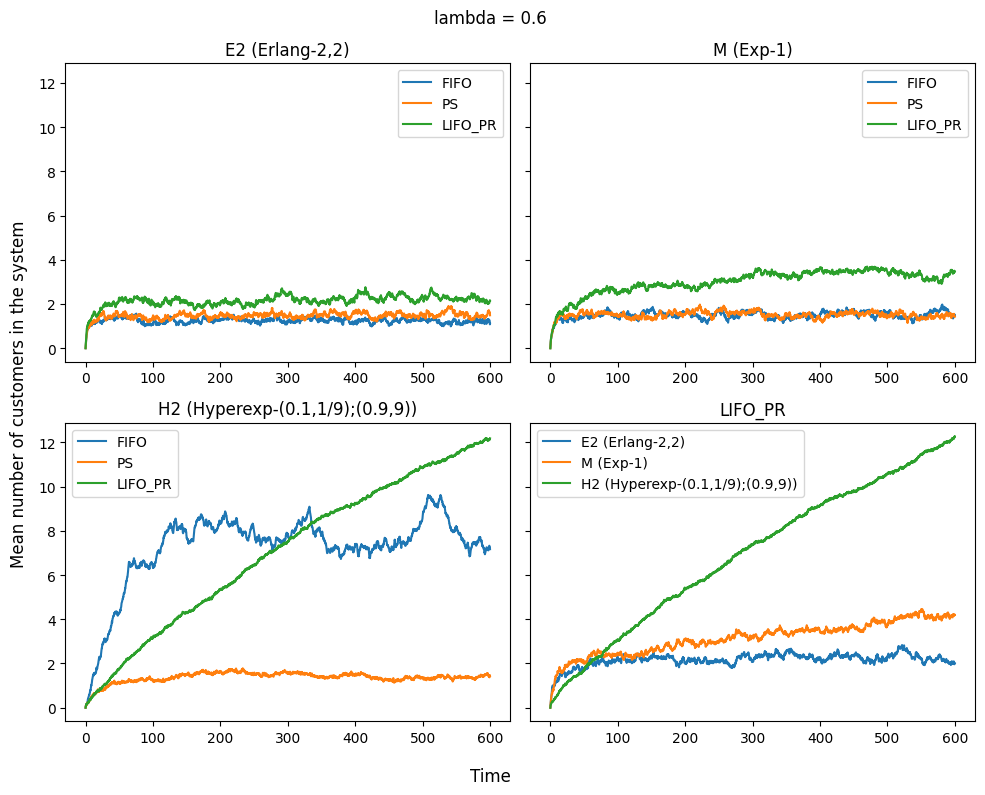

In [80]:
lmda = 0.6 
plot_all(lmda)

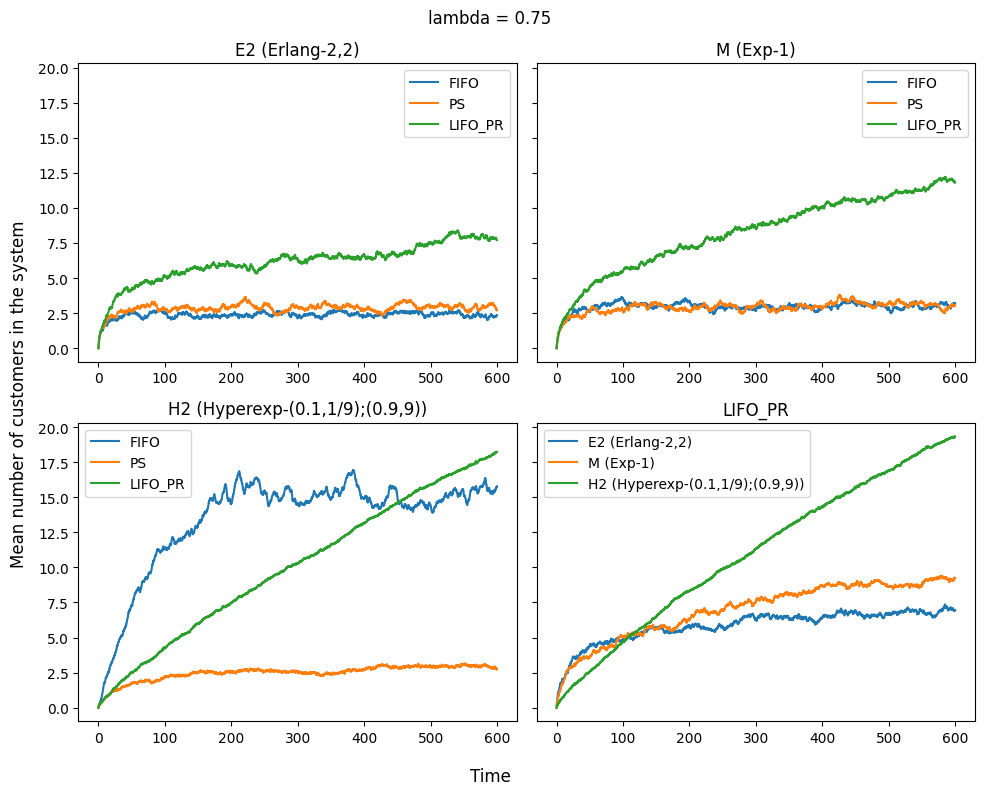

In [85]:
lmda = 0.75
plot_all(lmda)

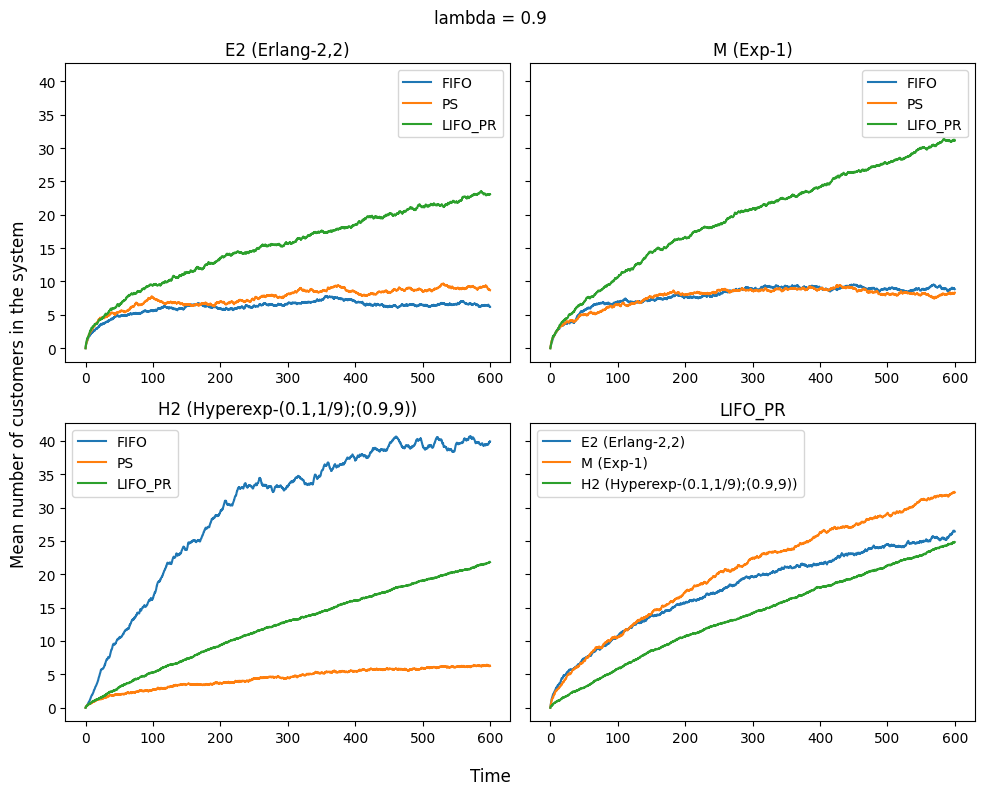

In [84]:
lmda = 0.9 
plot_all(lmda)

#### Observations:
- LIFO_PR much more than FIFO and PS for E2 and M (expected since both these distributions are kind of uniform, i.e. systematic and if normal processing happens i.e. First In First Out or Processor sharing, jobs will get out of the queue quickly).
- However, in case of H2, if one job of large procesing time enters the queue, if processing is by FIFO, this job will make all other jobs wait a lot due to which mean number of jobs int the system will increase. However, if the same is LIFO_PR, this job will get pushed behind and other (possibly smaller) jobs will get in front of the queue and be processed quickly and released, thus leading to smaller number of jobs in the queue. Hence, in case of H2, LIFO_PR will have less number of jobs in the queue than FIFO.
- FIFO gives out maximum number of people in the queue when the service distribution is H2.
- For LIFO_PR, it is kind of the opposite. LIFO_PR has the least number of people in the system when the service distribution is H2.
- PS almost same for all (expected since its processor sharing, so kind of agnostic to the service distribution since everything gets amortized over jobs in the queue).